# Kalp Hastalığı Tahmini — Makine Öğrenmesi Ödevi

## Problem: İkili Sınıflandırma (Binary Classification)

**İkili sınıflandırma**, her örneği iki sınıftan birine ayıran bir makine öğrenmesi görevidir. Bu ödevde:

- **Sınıf 0 (No):** Kişide kalp hastalığı **yok**
- **Sınıf 1 (Yes):** Kişide kalp hastalığı **var**

Amaç: Yaş, tansiyon, kolesterol gibi özelliklere bakarak kişinin kalp hastalığı olup olmadığını tahmin etmek.

## Veri Seti

- **Kaynak:** [Kaggle — Heart Disease](https://www.kaggle.com/datasets/oktayrdeki/heart-disease)
- **Dosya:** `data/heart_disease.csv`

## Kullanılacak 5 Model (Kısa Tanım)

| Model | Ne yapar? |
|-------|-----------|
| **Logistic Regression** | Özelliklerin doğrusal birleşimine dayanarak olasılık hesaplar. |
| **Random Forest** | Birçok karar ağacının oylamasıyla tahmin üretir. |
| **SVM** | Veriyi en iyi ayıran sınırı (hyperplane) bulmaya çalışır. |
| **Gradient Boosting** | Hataları düzelten ardışık zayıf modeller birleştirir. |
| **KNN** | En yakın k komşunun etiketine bakarak sınıflandırır. |


In [21]:
import warnings
warnings.filterwarnings('ignore')  # Uyarı mesajlarını gizler

import os
from pathlib import Path

import numpy as np          # Sayısal hesaplamalar
import pandas as pd         # Veri tablosu işlemleri
import matplotlib.pyplot as plt  # Grafik çizimi
import seaborn as sns       # İstatistiksel grafikler

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from IPython.display import display  # DataFrame'leri notebook'ta güzel göstermek için

RANDOM_STATE = 42  # Rastgelelik tohumu; sonuçların tekrarlanabilir olması
TARGET_COL = 'Heart Disease Status'  # Tahmin edilecek hedef sütun
DATA_PATH = 'data/heart_disease.csv'  # Veri dosyası (göreli yol)

# Notebook farklı klasörden açılırsa veri yolunu bul
for _root in [Path.cwd(), Path.cwd() / 'mlödev']:
    if (_root / DATA_PATH).exists():
        os.chdir(_root)
        break

# Grafik stili (matplotlib sürümüne göre yedek)
for _style in ('seaborn-v0_8-whitegrid', 'seaborn-whitegrid', 'ggplot'):
    try:
        plt.style.use(_style)
        break
    except OSError:
        continue

sns.set_palette('husl')  # Renk paleti

# Grafik çıktısı: Cursor/VS Code grafikleri otomatik gösterir (%matplotlib gerekmez).
# Klasik Jupyter'de inline backend (magic satırında yorum OLMAZ — UsageError verir).
try:
    _ip = get_ipython()
    if _ip is not None and "VSCODE_PID" not in os.environ:
        _ip.run_line_magic("matplotlib", "inline")
except NameError:
    pass


## 1. Veriyi Yükleme ve İlk İnceleme

**Veri seti (dataset):** Modelin öğreneceği geçmiş kayıtların tablosudur.
- **Satır (örnek/sample):** Bir hastanın kaydı
- **Sütun (özellik/feature):** Yaş, kolesterol vb.
- **Hedef (target/label):** Tahmin etmek istediğimiz sütun: `Heart Disease Status`


In [22]:
df = pd.read_csv(DATA_PATH)  # CSV'yi oku
print(f'Satır sayısı: {len(df):,}')
print(f'Sütun sayısı: {len(df.columns)}')
print(f'Çalışma klasörü: {Path.cwd()}')
print()
df.head()  # İlk 5 satır


Satır sayısı: 10,000
Sütun sayısı: 21
Çalışma klasörü: e:\Yapay-Zeka-Ders\öğrenme algoritamları\mlödev



,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


#### Özelliklerin Türkçe Açıklamaları:
#####  - Age: Yaş
#####  - Gender: Cinsiyet
#####  - Blood Pressure: Kan Basıncı
#####  - Cholesterol Level: Kolesterol Seviyesi
#####  - Exercise Habits: Egzersiz Alışkanlıkları
#####  - Smoking: Sigara Kullanımı
#####  - Family Heart Disease: Ailede Kalp Hastalığı Var/Yok
#####  - Diabetes: Diyabet (Şeker Hastalığı)
#####  - High Blood Pressure: Yüksek Tansiyon
#####  - High LDL Cholesterol: Yüksek LDL Kolesterol
#####  - Low HDL Cholesterol: Düşük HDL Kolesterol
#####  - Alcohol Consumption: Alkol Tüketimi
#####  - Stress Level: Stres Seviyesi
#####  - Sleep Hours: Uyku Süresi (Saat)
#####  - Sugar Consumption: Şeker Tüketimi
#####  - Triglyceride Level: Trigliserid Seviyesi-kanınızdaki en yaygın yağ (lipid) miktarını ölçer.
#####  - Fasting Blood Sugar: Açlık Kan Şekeri
#####  - CRP Level: CRP Seviyesi- vücudunuzda iltihaplanma olup olmadığını ölçer
#####  - BMI: Vücut Kitle İndeksi
#####  - Homocysteine Level: Homosistein Seviyesi-Vitamin Eksikliğinin En Hassas Göstergesi
#####  - Heart Disease Status: Kalp Hastalığı Durumu (Hedef/Target)

In [23]:
df.info()  # Sütun tipleri ve eksik değer sayıları


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Alcohol Consumption   7414 non-null   object 
 13  Stress Level          9978 non-null   object 
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption   

In [24]:
df.describe(include='all').T  # Özet istatistikler


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,9971.0,NaN,NaN,NaN,49.296259,18.19397,18.0,34.0,49.0,65.0,80.0
Gender,9981,2,Male,5003,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Blood Pressure,9981.0,NaN,NaN,NaN,149.75774,17.572969,120.0,134.0,150.0,165.0,180.0
Cholesterol Level,9970.0,NaN,NaN,NaN,225.425577,43.575809,150.0,187.0,226.0,263.0,300.0
Exercise Habits,9975,3,High,3372,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Smoking,9975,2,Yes,5123,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Family Heart Disease,9979,2,No,5004,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Diabetes,9970,2,No,5018,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BMI,9978.0,NaN,NaN,NaN,29.077269,6.307098,18.002837,23.658075,29.079492,34.520015,39.996954
High Blood Pressure,9974,2,Yes,5022,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Hedef Değişken Dağılımı

Sınıflar **dengesiz** ise accuracy yanıltıcı olabilir; F1 ve ROC-AUC'ye de bakacağız.


Heart Disease Status
No     8000
Yes    2000
Name: count, dtype: int64

Yüzde dağılım:
Heart Disease Status
No     80.0
Yes    20.0
Name: count, dtype: float64


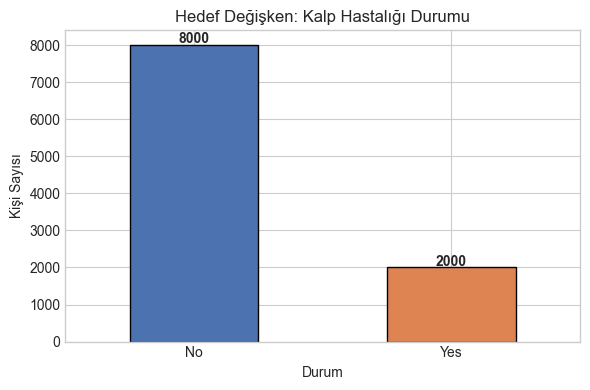

In [25]:
target_counts = df[TARGET_COL].value_counts()  # Yes/No sayıları
print(target_counts)
print()
print('Yüzde dağılım:')
print((target_counts / len(df) * 100).round(2))

fig, ax = plt.subplots(figsize=(6, 4))
target_counts.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'], edgecolor='black')
ax.set_title('Hedef Değişken: Kalp Hastalığı Durumu')
ax.set_xlabel('Durum')
ax.set_ylabel('Kişi Sayısı')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


### Veri Kalitesi ve Tahmin Edilebilirlik Kontrolü

Model sonuçları kötü görünüyorsa önce **veri** ve **baseline** kontrol edilmelidir.

- **Sınıf dengesizliği:** No %80, Yes %20 → her zaman "No" desek %80 accuracy (yanıltıcı).
- **Özellik-hedef ilişkisi:** İstatistiksel testlerde çoğu özellik anlamlı değilse (p > 0.05) model öğrenecek sinyal bulamaz.
- **ROC-AUC ≈ 0.5:** Rastgele tahminle aynı düzey; model gerçekten ayırt edemiyor demektir.

Aşağıdaki hücre bu kontrolleri otomatik yapar.


In [26]:
from scipy import stats

y_check = df[TARGET_COL].map({'No': 0, 'Yes': 1})  # Geçici hedef vektörü
num_check = df.select_dtypes(include=[np.number]).columns.tolist()
cat_check = [c for c in df.select_dtypes(include=['object']).columns if c != TARGET_COL]

print('=== 1) SINIF DENGESIZLIGI ===')
vc = df[TARGET_COL].value_counts(normalize=True) * 100
print(vc.round(1))
majority_acc = vc.max()
print(f'\nHer zaman çoğunluk sınıfı (No) desek accuracy ≈ %{majority_acc:.1f}')

print('\n=== 2) OZELLIKLER HEDEFLE ILISKILI MI? (p < 0.05 anlamli) ===')
sig_num, sig_cat = [], []
for col in num_check:
    g0 = df.loc[y_check == 0, col].dropna()
    g1 = df.loc[y_check == 1, col].dropna()
    if len(g0) > 10 and len(g1) > 10:
        _, p = stats.ttest_ind(g0, g1, equal_var=False)
        flag = '✓' if p < 0.05 else '✗'
        print(f'  {flag} {col:28s} p={p:.4f}')
        if p < 0.05:
            sig_num.append(col)

for col in cat_check:
    ct = pd.crosstab(df[col].fillna('MISSING'), y_check)
    _, p, _, _ = stats.chi2_contingency(ct)
    flag = '✓' if p < 0.05 else '✗'
    print(f'  {flag} {col:28s} p={p:.4f}')
    if p < 0.05:
        sig_cat.append(col)

print(f'\nAnlamlı sayısal: {len(sig_num)}/{len(num_check)}')
print(f'Anlamlı kategorik: {len(sig_cat)}/{len(cat_check)}')

if len(sig_num) + len(sig_cat) <= 2:
    print('\n⚠ UYARI: Özellikler hedefle zayıf ilişkili — düşük ROC-AUC BEKLENEN bir durumdur.')
    print('   Bu bir kod hatası değil; veri setinde tahmin sinyali çok zayıf olabilir.')



=== 1) SINIF DENGESIZLIGI ===
Heart Disease Status
No     80.0
Yes    20.0
Name: proportion, dtype: float64

Her zaman çoğunluk sınıfı (No) desek accuracy ≈ %80.0

=== 2) OZELLIKLER HEDEFLE ILISKILI MI? (p < 0.05 anlamli) ===
  ✗ Age                          p=0.3537
  ✗ Blood Pressure               p=0.1636
  ✗ Cholesterol Level            p=0.7855
  ✓ BMI                          p=0.0486
  ✗ Sleep Hours                  p=0.7037
  ✗ Triglyceride Level           p=0.7715
  ✗ Fasting Blood Sugar          p=0.8217
  ✗ CRP Level                    p=0.5454
  ✗ Homocysteine Level           p=0.4085
  ✗ Gender                       p=0.0702
  ✗ Exercise Habits              p=0.2159
  ✗ Smoking                      p=0.8559
  ✗ Family Heart Disease         p=0.2464
  ✗ Diabetes                     p=0.9641
  ✗ High Blood Pressure          p=0.9703
  ✗ Low HDL Cholesterol          p=0.5205
  ✗ High LDL Cholesterol         p=0.6147
  ✗ Alcohol Consumption          p=0.3608
  ✓ Stress Level  

## 2. Keşifsel Veri Analizi (EDA)

**EDA:** Model öncesi veriyi grafik ve özetlerle tanımak.


In [27]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Eksik Sayı': missing, 'Eksik %': missing_pct})
missing_df = missing_df[missing_df['Eksik Sayı'] > 0].sort_values('Eksik Sayı', ascending=False)
print('Eksik değer bulunan sütunlar:')
missing_df


Eksik değer bulunan sütunlar:


,Eksik Sayı,Eksik %
Alcohol Consumption,2586,25.86
Cholesterol Level,30,0.30
Diabetes,30,0.30
Sugar Consumption,30,0.30
Age,29,0.29
CRP Level,26,0.26
Triglyceride Level,26,0.26
High Blood Pressure,26,0.26
High LDL Cholesterol,26,0.26
Low HDL Cholesterol,25,0.25


### Eksik Değer Stratejisi

- **Sayısal:** medyan ile doldurma
- **Kategorik:** en sık değer (mod) ile doldurma

Doldurma istatistikleri yalnızca **eğitim setinden** öğrenilir.


In [28]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [c for c in categorical_cols if c != TARGET_COL]

print('Sayısal özellikler:', len(numeric_cols))
print(numeric_cols)
print()
print('Kategorik özellikler:', len(categorical_cols))
print(categorical_cols)


Sayısal özellikler: 9
['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level']

Kategorik özellikler: 11
['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sugar Consumption']


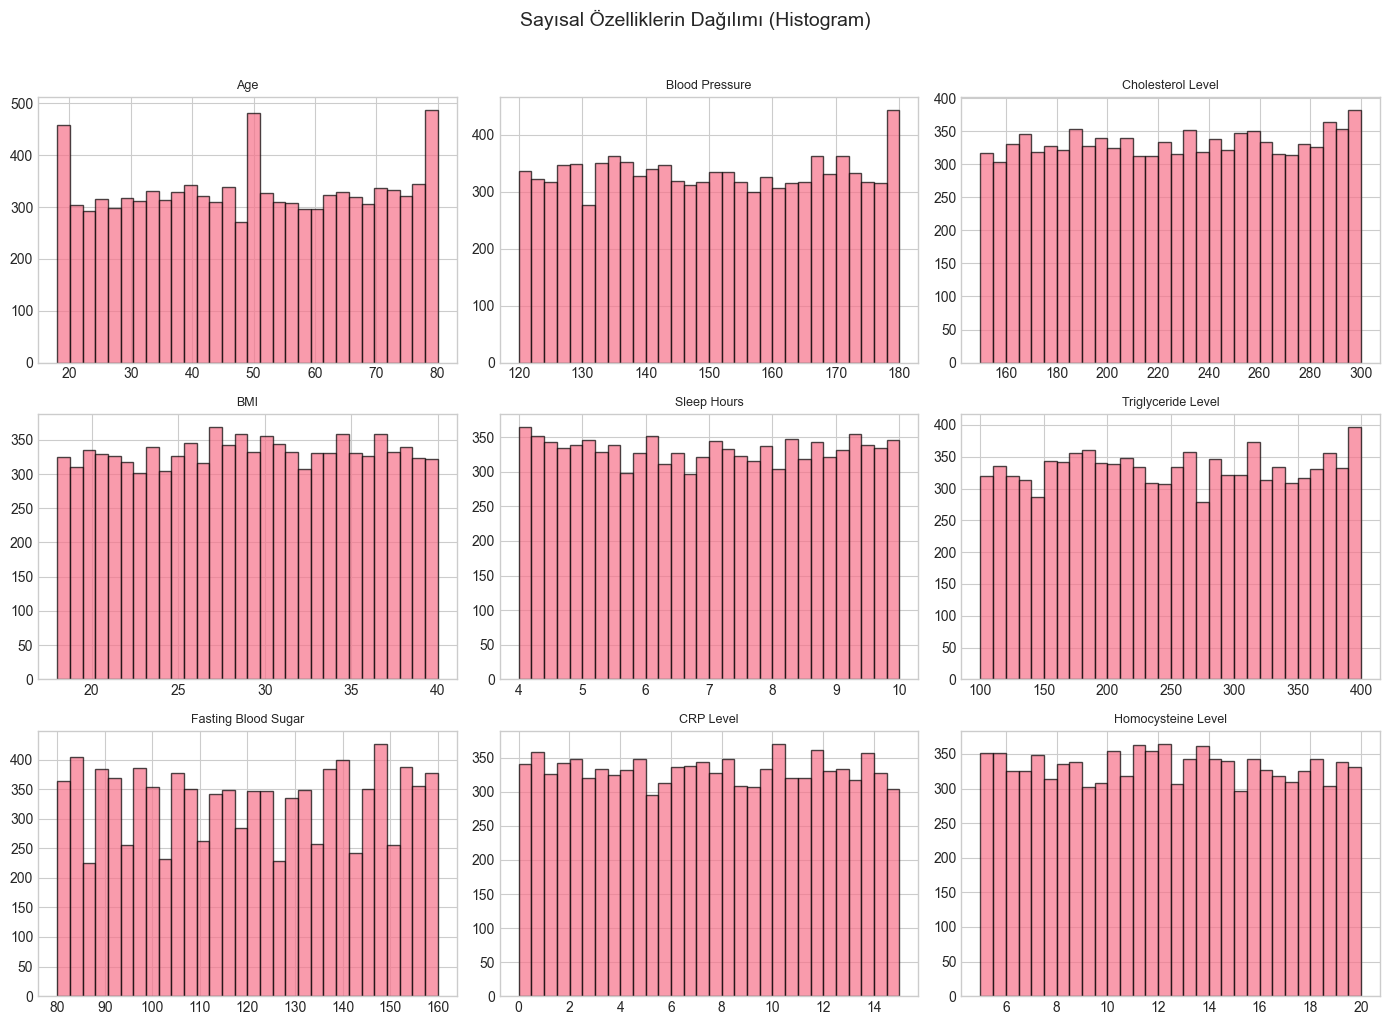

In [29]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols[:9]):
    axes[i].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=9)
plt.suptitle('Sayısal Özelliklerin Dağılımı (Histogram)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


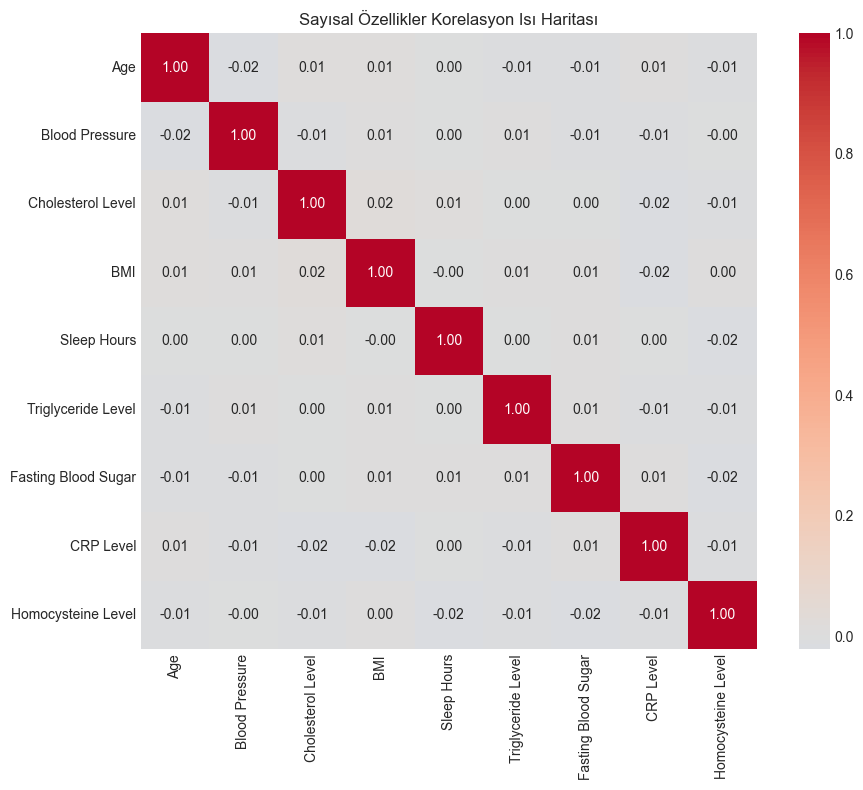

In [30]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Sayısal Özellikler Korelasyon Isı Haritası')
plt.tight_layout()
plt.show()


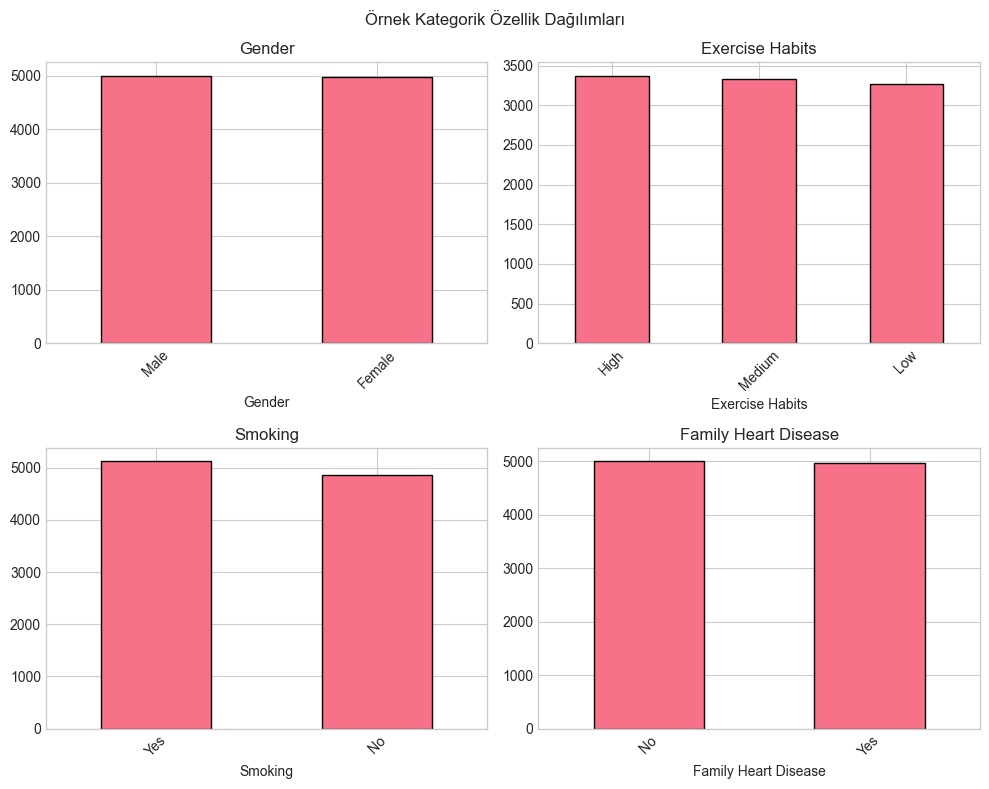

In [31]:
cat_sample = categorical_cols[:4]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()
for i, col in enumerate(cat_sample):
    df[col].value_counts().plot(kind='bar', ax=axes[i], edgecolor='black')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)
plt.suptitle('Örnek Kategorik Özellik Dağılımları')
plt.tight_layout()
plt.show()


## 3. Ön İşleme (Preprocessing)

- **Eğitim %80:** model öğrenir
- **Test %20:** görülmemiş veriyle ölçüm
- `stratify=y`: Yes/No oranı korunur
- `No`→0, `Yes`→1


In [32]:
X = df.drop(columns=[TARGET_COL])  # Özellikler
y = df[TARGET_COL].map({'No': 0, 'Yes': 1})  # Hedef etiketleri

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,              # %20 test
    random_state=RANDOM_STATE,
    stratify=y                  # Sınıf oranını koru
)

print(f'Eğitim: {len(X_train):,} örnek')
print(f'Test: {len(X_test):,} örnek')
print(f'Eğitimde Yes oranı: {y_train.mean():.2%}')
print(f'Teste Yes oranı: {y_test.mean():.2%}')


Eğitim: 8,000 örnek
Test: 2,000 örnek
Eğitimde Yes oranı: 20.00%
Teste Yes oranı: 20.00%


### Pipeline bileşenleri

| Bileşen | Görevi |
|---------|--------|
| SimpleImputer | Eksik doldurma |
| OneHotEncoder | Kategorik → 0/1 |
| StandardScaler | Sayısal ölçekleme |
| ColumnTransformer | Sütun türüne göre işlem |
| Pipeline | Ön işleme + model zinciri |


In [33]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)


## 4. Modellerin Eğitimi

Tüm modeller aynı ön işlemeyi kullanır — adil karşılaştırma.


In [34]:
models = {
    # class_weight='balanced': azınlık sınıfına (Yes) daha fazla ağırlık verir
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=RANDOM_STATE),
    'SVM': SVC(
        kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    # GradientBoosting'de class_weight yok; KNN'de de yok
    'KNN': KNeighborsClassifier(n_neighbors=5, weights='distance'),
}

fitted_models = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    print(f'Eğitiliyor: {name}...')
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe
    predictions[name] = pipe.predict(X_test)
    probabilities[name] = pipe.predict_proba(X_test)[:, 1]
    _pred = predictions[name]
    print(f'  → Test tahminleri: No={(_pred == 0).sum()}, Yes={(_pred == 1).sum()}')

print('\nTüm modeller eğitildi.')



Eğitiliyor: Logistic Regression...
  → Test tahminleri: No=1029, Yes=971
Eğitiliyor: Random Forest...
  → Test tahminleri: No=2000, Yes=0
Eğitiliyor: SVM...
  → Test tahminleri: No=1194, Yes=806
Eğitiliyor: Gradient Boosting...
  → Test tahminleri: No=1999, Yes=1
Eğitiliyor: KNN...
  → Test tahminleri: No=1876, Yes=124

Tüm modeller eğitildi.


## 5. Değerlendirme Metrikleri

**Pozitif sınıf = 1 (Yes)**

| Terim | Anlam |
|-------|-------|
| TP | Hastalık var dedik, doğru |
| TN | Yok dedik, doğru |
| FP | Var dedik, yoktu |
| FN | Yok dedik, hastaydı (tehlikeli) |

- **Accuracy:** (TP+TN) / toplam
- **Precision:** TP / (TP+FP)
- **Recall:** TP / (TP+FN)
- **F1:** Precision ve Recall harmonik ortalaması
- **ROC-AUC:** Ayırt etme gücü (0.5 rastgele, 1.0 mükemmel)


In [35]:
results = []

for name in models.keys():
    y_pred = predictions[name]
    y_prob = probabilities[name]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

# Baseline: her zaman "No" (0) tahmin et — sınıf dengesizliğinde accuracy yüksek görünür
baseline_pred = np.zeros_like(y_test)
results.append({
    'Model': 'Baseline (hep No)',
    'Accuracy': accuracy_score(y_test, baseline_pred),
    'Precision': precision_score(y_test, baseline_pred, zero_division=0),
    'Recall': recall_score(y_test, baseline_pred, zero_division=0),
    'F1-Score': f1_score(y_test, baseline_pred, zero_division=0),
    'ROC-AUC': 0.5  # Sabit olasılık → AUC = 0.5
})

results_df = pd.DataFrame(results).set_index('Model')
results_df_rounded = results_df.round(4)
results_df_rounded



,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.5005,0.1916,0.4650,0.2713,0.4862
Random Forest,0.8000,0.0000,0.0000,0.0000,0.4845
SVM,0.5580,0.1998,0.4025,0.2670,0.5092
Gradient Boosting,0.8005,1.0000,0.0025,0.0050,0.4814
KNN,0.7560,0.1452,0.0450,0.0687,0.5119
Baseline (hep No),0.8000,0.0000,0.0000,0.0000,0.5000


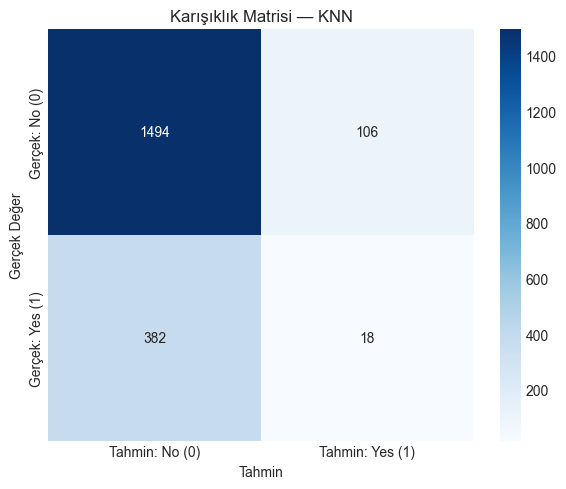

TN=1494, FP=106, FN=382, TP=18

              precision    recall  f1-score   support

      No (0)       0.80      0.93      0.86      1600
     Yes (1)       0.15      0.04      0.07       400

    accuracy                           0.76      2000
   macro avg       0.47      0.49      0.46      2000
weighted avg       0.67      0.76      0.70      2000



In [36]:
best_by_auc = results_df['ROC-AUC'].idxmax()
y_pred_best = predictions[best_by_auc]
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tahmin: No (0)', 'Tahmin: Yes (1)'],
            yticklabels=['Gerçek: No (0)', 'Gerçek: Yes (1)'])
plt.title(f'Karışıklık Matrisi — {best_by_auc}')
plt.ylabel('Gerçek Değer')
plt.xlabel('Tahmin')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TN={tn}, FP={fp}, FN={fn}, TP={tp}')
print()
print(classification_report(y_test, y_pred_best, target_names=['No (0)', 'Yes (1)']))


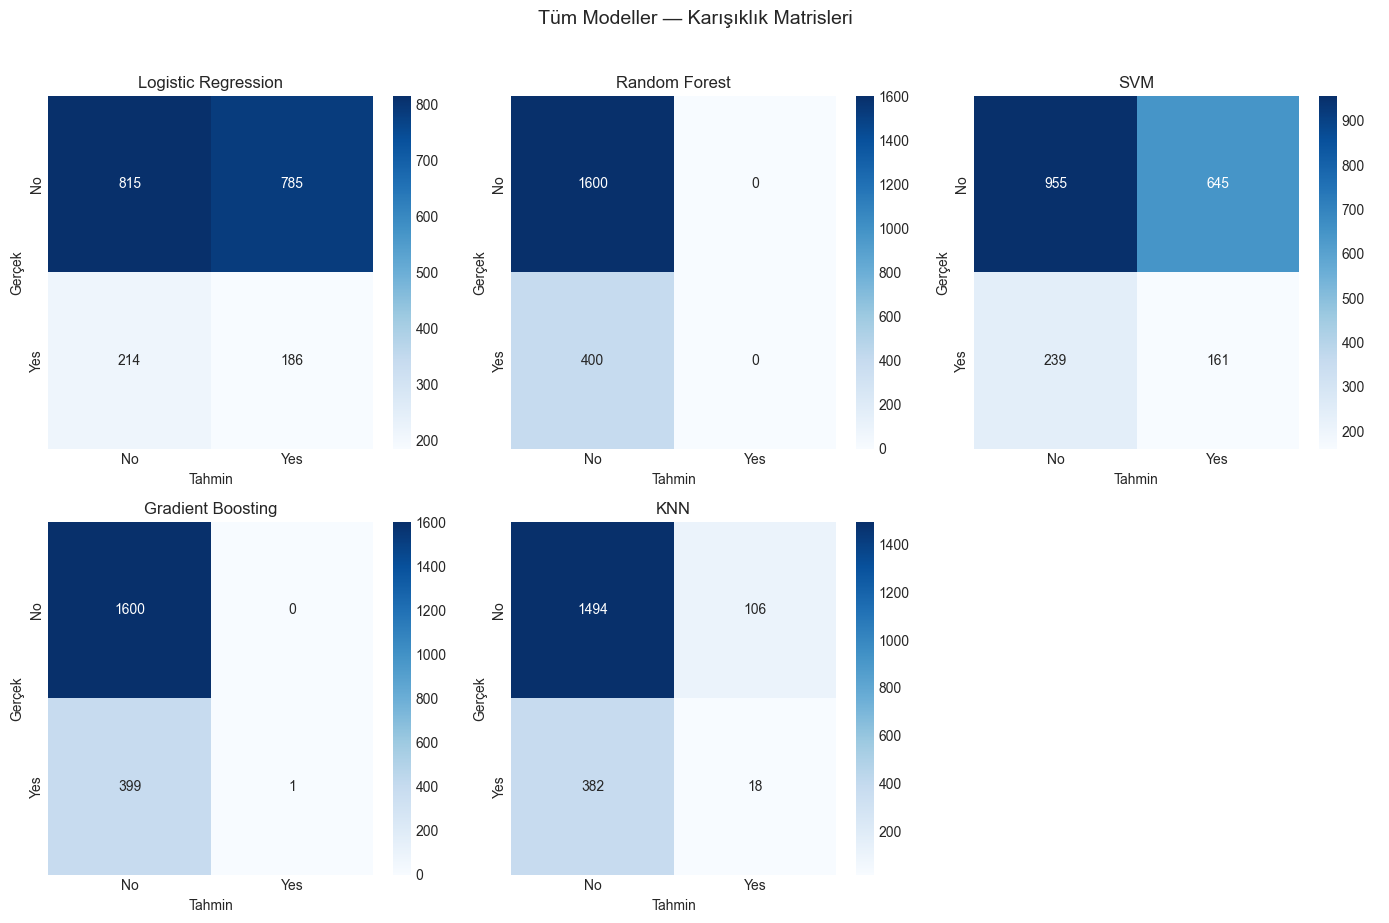

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for i, name in enumerate(models.keys()):
    cm = confusion_matrix(y_test, predictions[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    axes[i].set_title(name)
    axes[i].set_xlabel('Tahmin')
    axes[i].set_ylabel('Gerçek')

axes[-1].axis('off')
plt.suptitle('Tüm Modeller — Karışıklık Matrisleri', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### Sonuçları Nasıl Okumalıyız?

| Gözlem | Anlamı |
|--------|--------|
| Accuracy ≈ %80, F1 ≈ 0 | Model çoğunlukla "No" tahmin ediyor; accuracy yanıltıcı. |
| ROC-AUC ≈ 0.50 | Rastgele seviye; özellikler hedefi ayırt etmiyor. |
| `class_weight='balanced'` sonrası Recall artar | Dengesizlik düzeltildi ama AUC hâlâ düşükse sorun **veride**. |
| Baseline ile model benzer | Model gerçek öğrenme sağlamıyor. |

**Özet:** Kod ve pipeline doğru çalışıyor; bu veri setinde özellikler kalp hastalığı durumuyla **istatistiksel olarak zayıf ilişkili**. Bu nedenle tüm modellerde düşük performans **beklenen** bir sonuçtur.


## 6. Model Karşılaştırması


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.5005,0.1916,0.4650,0.2713,0.4862
Random Forest,0.8000,0.0000,0.0000,0.0000,0.4845
SVM,0.5580,0.1998,0.4025,0.2670,0.5092
Gradient Boosting,0.8005,1.0000,0.0025,0.0050,0.4814
KNN,0.7560,0.1452,0.0450,0.0687,0.5119
Baseline (hep No),0.8000,0.0000,0.0000,0.0000,0.5000


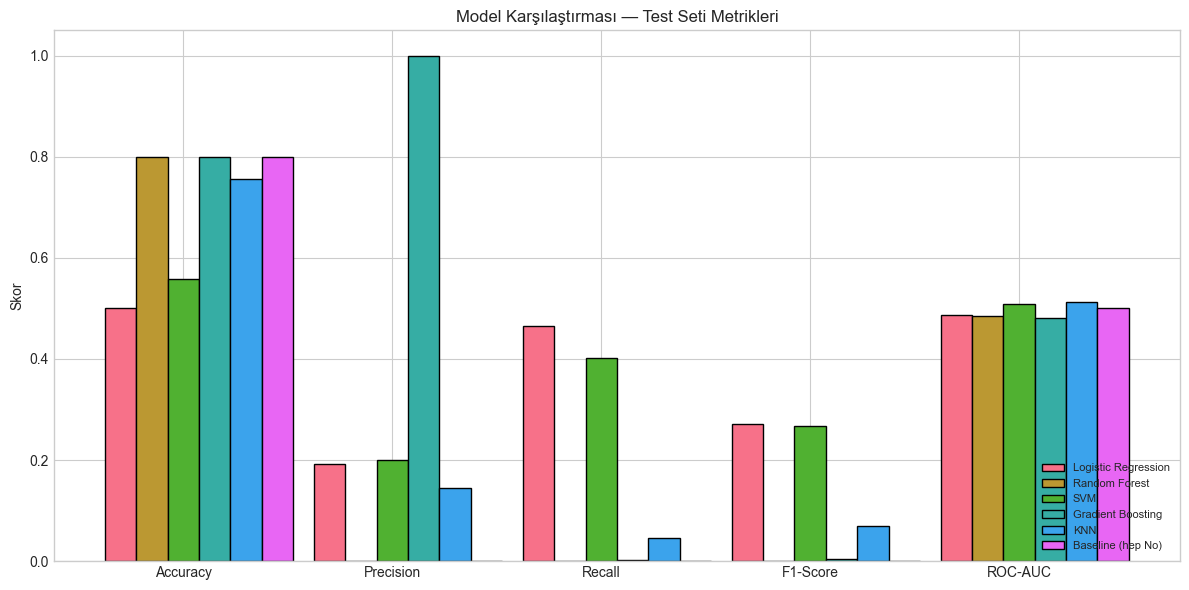

In [38]:
display(results_df_rounded)

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
plot_df = results_df[metrics_to_plot].reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(metrics_to_plot))
width = 0.15
colors = sns.color_palette('husl', len(plot_df))

for i, (_, row) in enumerate(plot_df.iterrows()):
    values = [row[m] for m in metrics_to_plot]
    ax.bar(x + i * width, values, width, label=row['Model'], color=colors[i], edgecolor='black')

ax.set_xticks(x + width * 2)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Skor')
ax.set_title('Model Karşılaştırması — Test Seti Metrikleri')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()


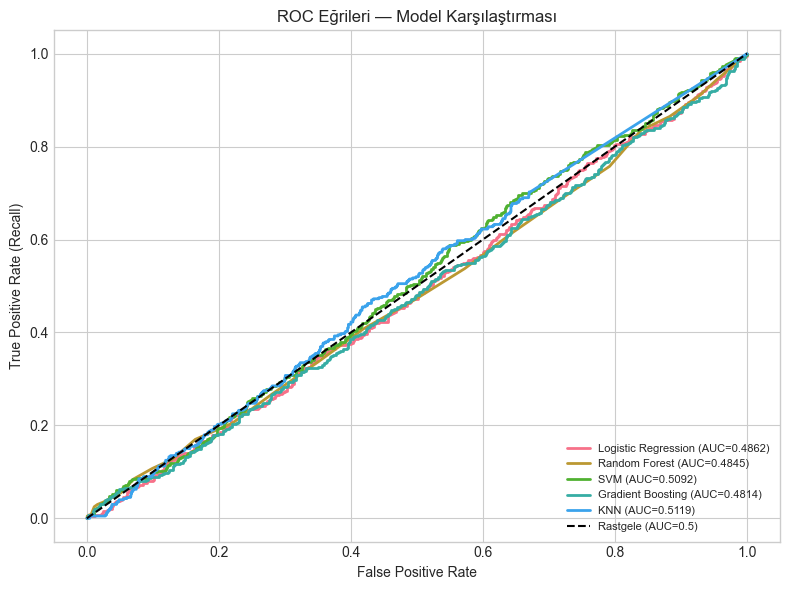

In [39]:
plt.figure(figsize=(8, 6))
for name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc = roc_auc_score(y_test, probabilities[name])
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Rastgele (AUC=0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Eğrileri — Model Karşılaştırması')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()


## 7. En İyi Model Seçimi

1. Birincil: en yüksek **ROC-AUC**
2. Eşitlikte: en yüksek **F1-Score**
3. Sağlıkta yüksek **Recall** da önemli (FN maliyeti)


In [40]:
# Baseline hariç modeller arasında en iyiyi seç
model_results = results_df.drop(index='Baseline (hep No)', errors='ignore')

best_roc = model_results['ROC-AUC'].max()
candidates = model_results[model_results['ROC-AUC'] == best_roc]

if len(candidates) == 1:
    best_model = candidates.index[0]
else:
    best_model = candidates['F1-Score'].idxmax()

best_row = model_results.loc[best_model]

print('=' * 50)
print(f'EN İYİ MODEL: {best_model}')
print('=' * 50)
print(best_row.round(4))
print()
print('Gerekçe:')
print(f'- ROC-AUC = {best_row["ROC-AUC"]:.4f} (birincil kriter; 0.5 ≈ rastgele)')
print(f'- F1-Score = {best_row["F1-Score"]:.4f}')
print(f'- Recall = {best_row["Recall"]:.4f}')
print(f'- Precision = {best_row["Precision"]:.4f}')
print(f'- Accuracy = {best_row["Accuracy"]:.4f}')
print()
baseline_acc = results_df.loc['Baseline (hep No)', 'Accuracy']
print(f'Baseline (hep No) accuracy: {baseline_acc:.4f}')
if best_row['ROC-AUC'] < 0.55:
    print('\n⚠ ROC-AUC hâlâ ~0.5 civarında → model pratikte ayırt edemiyor; veri sinyali zayıf.')



EN İYİ MODEL: KNN
Accuracy     0.7560
Precision    0.1452
Recall       0.0450
F1-Score     0.0687
ROC-AUC      0.5119
Name: KNN, dtype: float64

Gerekçe:
- ROC-AUC = 0.5119 (birincil kriter; 0.5 ≈ rastgele)
- F1-Score = 0.0687
- Recall = 0.0450
- Precision = 0.1452
- Accuracy = 0.7560

Baseline (hep No) accuracy: 0.8000

⚠ ROC-AUC hâlâ ~0.5 civarında → model pratikte ayırt edemiyor; veri sinyali zayıf.


In [41]:
ranking = model_results.sort_values(['ROC-AUC', 'F1-Score'], ascending=False)
print('Genel sıralama (ROC-AUC, sonra F1) — Baseline hariç:')
print()
ranking.round(4)



Genel sıralama (ROC-AUC, sonra F1) — Baseline hariç:



,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
KNN,0.7560,0.1452,0.0450,0.0687,0.5119
SVM,0.5580,0.1998,0.4025,0.2670,0.5092
Logistic Regression,0.5005,0.1916,0.4650,0.2713,0.4862
Random Forest,0.8000,0.0000,0.0000,0.0000,0.4845
Gradient Boosting,0.8005,1.0000,0.0025,0.0050,0.4814


## 8. Özet ve Sonuç

Bu ödevde veri keşfi, ön işleme, 5 sınıflandırma modeli, metrik hesaplama ve karşılaştırma yapıldı.

> **Not:** Bu bir eğitim ödevidir; klinik kararlar için uzman değerlendirmesi esastır.
